# EOSC 454 Assignment 3
### February 27, 2026
### Ian Hartley

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from numbers import Real
import numpy.typing as npt
import scipy.sparse as sp

## Q1: Forward simulation

In [129]:
def generate_kernel(x: npt.NDArray,j:Real,p:Real,q:Real):
    """
    Generate a kernel

    :param x: vector of position values
    :param j: scalar
    :param p: scalar
    :param q: scalar
    """

    return np.exp(j*p*x)*np.cos(2*np.pi*j*q*x)

n_cells = 100
x_nodes = np.linspace(0, 1, n_cells+1)


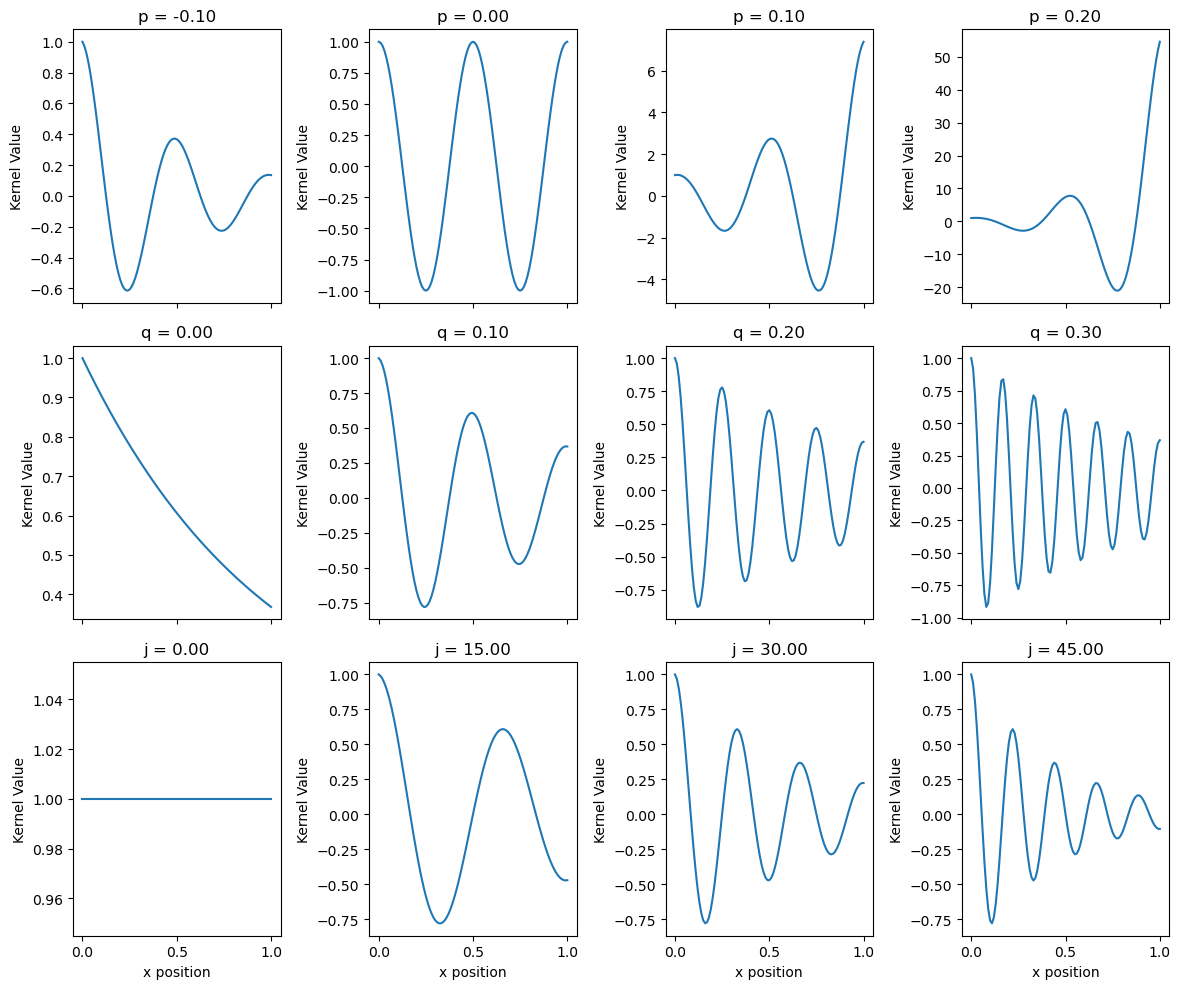

In [ ]:
defaults = {
    "p":    -0.05,
    "q": 0.1,
    "j": 20,
}
sweeps = {
    "p":    np.linspace(-0.1, 0.2, 4),
    "q": np.linspace(-0,0.3, 4),
    "j": np.linspace(0, 45, 4),
}

# create 4x3 plot grid
fig, ax = plt.subplots(3, 4, figsize=(12, 10), sharex=True)

for row, (param, values) in enumerate(sweeps.items()):
    for col, val in enumerate(values):
        params = defaults.copy()
        params[param] = val

        kernel = generate_kernel( x_nodes, params["j"], params["p"], params["q"])

        ax = ax[row, col]
        ax.plot(x_nodes, kernel)
        ax.set_title(f"{param} = {val:.2f}")
        ax.set_ylabel("Kernel Value")

for ax in ax[-1]:
    ax.set_xlabel("x position")

plt.tight_layout()
plt.show()

## Design Model

In [131]:
def build_model(x_cells, x_boxcar_min = 0.75, x_boxcar_max = 0.92, amplitude_boxcar = -0.8,
                gaussian_amplitude = 0.6, gaussian_mean = 1-0.7, gaussian_std = 0.1):
    model = np.zeros_like(x_cells)
    inds_boxcar = ((x_cells < x_boxcar_max) & (x_cells > x_boxcar_min))
    model[inds_boxcar] = amplitude_boxcar
    gaussian = gaussian_amplitude * np.exp(
    -(x_cells - gaussian_mean)**2/(2*gaussian_std**2)
    )

    model = model + gaussian
    return model

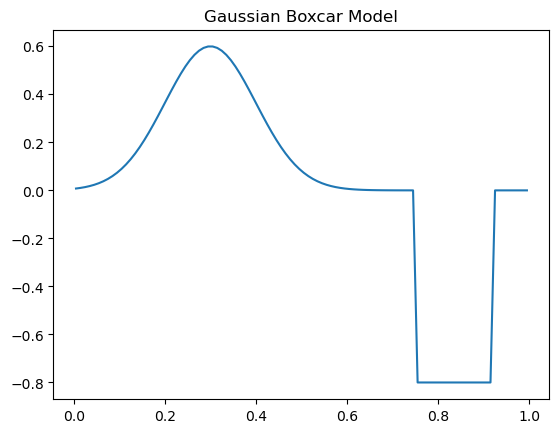

In [132]:
dx = np.diff(x_nodes)
x_cells = x_nodes[:-1]+dx/2
boxcar_amplitude = -0.8
gaussian_amplitude = 0.6
model = build_model(x_cells, amplitude_boxcar = boxcar_amplitude, gaussian_amplitude = gaussian_amplitude)

fig, ax = plt.subplots(1,1)
ax.set_title("Gaussian Boxcar Model")
ax.plot(x_cells, model)

In [133]:
def build_g_mtx(x_nodes: npt.NDArray, n_kernels: int, p: Real, q: Real, j0: Real, jN: Real):
    """
    Build the G matrix for the given parameters, j values are linearly spaced between j0 and jN.

    :param x_nodes: vector of position values
    :param n_kernels: number of kernels to use
    :param p: scalar
    :param q: scalar
    :param j0: scalar, starting value of j
    :param jN: scalar, ending value of j
    """

    j_values = np.linspace(j0, jN, n_kernels)

    n_nodes = len(x_nodes) 
    n_cells = n_nodes - 1

    # fill an empty matrix with kernels on nodes 
    Gnodes = np.zeros((n_cells+1, n_kernels))
    for k, jk in enumerate(j_values):
        Gnodes[:, k] = generate_kernel(x_nodes, jk, p, q)

    # averaging matrix from nodes to cells
    Ave = sp.spdiags([0.5*np.ones(n_nodes), 0.5*np.ones(n_nodes)], [0, 1], n_cells, n_nodes)

    # average Gnodes to cells
    Gcells = Ave @ Gnodes

    # integrate with delta x
    dx = np.diff(x_nodes)
    Deltax = sp.spdiags([dx], [0], n_cells, n_cells)

    # construct the full G matrix (N Data x N Cells) 
    G = (Gcells).T @ Deltax

    return G


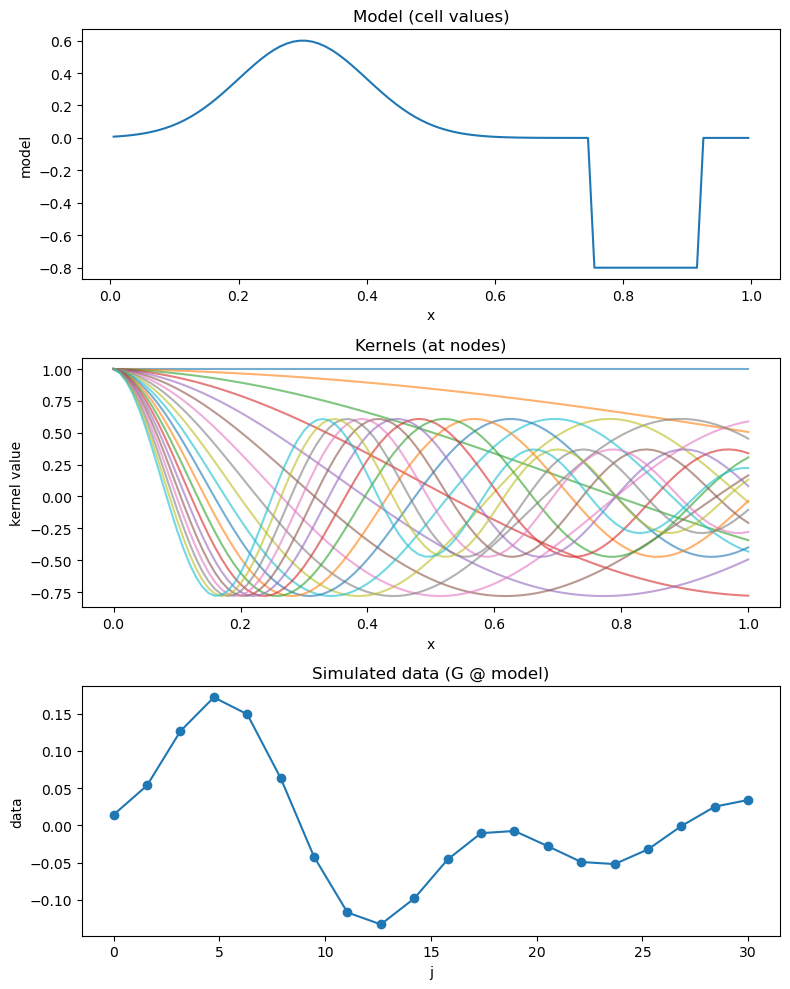

In [ ]:
n_kernels = 20
p = -0.05
q = 0.1
j0, jN = 0.0, 30.0

# build G (n_kernels x n_cells)
G = build_g_mtx(x_nodes, n_kernels, p, q, j0, jN)

# simulate data: (n_kernels,)
data = G @ model

# j values used
j_values = np.linspace(j0, jN, n_kernels)

fig, ax = plt.subplots(3, 1, figsize=(8, 10))

# model (cell-centered)
ax[0].plot(x_cells, model)
ax[0].set_title('Model (cell values)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('model')

# kernels (sampled at nodes)
for jk in j_values:
    ax[1].plot(x_nodes, generate_kernel(x_nodes, jk, p, q), alpha=0.6)
ax[1].set_title('Kernels (at nodes)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('kernel value')

# simulated data vs j
ax[2].plot(j_values, data, 'o-')
ax[2].set_title('Simulated data (G @ model)')
ax[2].set_xlabel('j')
ax[2].set_ylabel('data')

plt.tight_layout()
plt.show()

In [135]:
#check how sensitive the data is to changes in the model parameters
def compute_sensitivity(data1, data2, delta_amplitude):
    return np.linalg.norm(data1 -data2) / delta_amplitude

new_boxcar_amplitude = -0.3

model2 = build_model(x_cells, amplitude_boxcar = new_boxcar_amplitude, gaussian_amplitude = gaussian_amplitude)
data2 = G @ model2
sensitivity = compute_sensitivity(data, data2, new_boxcar_amplitude - boxcar_amplitude)
print(f"Sensitivity to boxcar amplitude change: {sensitivity:.4f}")

new_gaussian_amplitude = 1.0
model3 = build_model(x_cells, amplitude_boxcar = boxcar_amplitude, gaussian_amplitude = new_gaussian_amplitude)
data3 = G @ model3
sensitivity_gaussian = compute_sensitivity(data, data3, new_gaussian_amplitude - gaussian_amplitude)
print(f"Sensitivity to gaussian amplitude change: {sensitivity_gaussian:.4f}")

Sensitivity to boxcar amplitude change: 0.3237
Sensitivity to gaussian amplitude change: 0.5039


In [136]:
#check how changing q value affects the sensitivity of the data to changes in the model parameters

low_q = 0.05
high_q = 0.2
default_model = build_model(x_cells, amplitude_boxcar = boxcar_amplitude, gaussian_amplitude = gaussian_amplitude)
G_low_q = build_g_mtx(x_nodes, n_kernels, p, low_q, j0, jN)
G_high_q = build_g_mtx(x_nodes, n_kernels, p, high_q, j0, jN)
data_low_q = G_low_q @ default_model
data_high_q = G_high_q @ default_model
data2_low_q = G_low_q @ model2
data2_high_q = G_high_q @ model2
sensitivity_low_q = compute_sensitivity(data_low_q, data2_low_q, new_boxcar_amplitude - boxcar_amplitude)
sensitivity_high_q = compute_sensitivity(data_high_q, data2_high_q, new_boxcar_amplitude - boxcar_amplitude)
print(f"Sensitivity to boxcar amplitude change at low q ({low_q}): {sensitivity_low_q:.4f}")
print(f"Sensitivity to boxcar amplitude change at high q ({high_q}): {sensitivity_high_q:.4f}")
data3_low_q = G_low_q @ model3
data3_high_q = G_high_q @ model3
sensitivity_gaussian_low_q = compute_sensitivity(data_low_q, data3_low_q, new_gaussian_amplitude - gaussian_amplitude)
sensitivity_gaussian_high_q = compute_sensitivity(data_high_q, data3_high_q, new_gaussian_amplitude - gaussian_amplitude)
print(f"Sensitivity to gaussian amplitude change at low q ({low_q}): {sensitivity_gaussian_low_q:.4f}")
print(f"Sensitivity to gaussian amplitude change at high q ({high_q}): {sensitivity_gaussian_high_q:.4f}")

Sensitivity to boxcar amplitude change at low q (0.05): 0.3394
Sensitivity to boxcar amplitude change at high q (0.2): 0.2892
Sensitivity to gaussian amplitude change at low q (0.05): 0.5970
Sensitivity to gaussian amplitude change at high q (0.2): 0.3948


In [137]:
#check how changing p value affects the sensitivity of the data to changes in the model parameters
p_rapid_decay = -0.1
p_slow_decay = -0.01
G_rapid_decay = build_g_mtx(x_nodes, n_kernels, p_rapid_decay, q, j0, jN)
G_slow_decay = build_g_mtx(x_nodes, n_kernels, p_slow_decay, q, j0, jN)
data_rapid_decay = G_rapid_decay @ default_model
data_slow_decay = G_slow_decay @ default_model
data2_rapid_decay = G_rapid_decay @ model2
data2_slow_decay = G_slow_decay @ model2
sensitivity_rapid_decay = compute_sensitivity(data_rapid_decay, data2_rapid_decay, new_boxcar_amplitude - boxcar_amplitude)
sensitivity_slow_decay = compute_sensitivity(data_slow_decay, data2_slow_decay, new_boxcar_amplitude - boxcar_amplitude)
print(f"Sensitivity to boxcar amplitude change at rapid decay (p={p_rapid_decay}): {sensitivity_rapid_decay:.4f}")
print(f"Sensitivity to boxcar amplitude change at slow decay (p={p_slow_decay}): {sensitivity_slow_decay:.4f}")
data3_rapid_decay = G_rapid_decay @ model3
data3_slow_decay = G_slow_decay @ model3
sensitivity_gaussian_rapid_decay = compute_sensitivity(data_rapid_decay, data3_rapid_decay, new_gaussian_amplitude - gaussian_amplitude)
sensitivity_gaussian_slow_decay = compute_sensitivity(data_slow_decay, data3_slow_decay, new_gaussian_amplitude - gaussian_amplitude)
print(f"Sensitivity to gaussian amplitude change at rapid decay (p={p_rapid_decay}): {sensitivity_gaussian_rapid_decay:.4f}")
print(f"Sensitivity to gaussian amplitude change at slow decay (p={p_slow_decay}): {sensitivity_gaussian_slow_decay:.4f}")


Sensitivity to boxcar amplitude change at rapid decay (p=-0.1): 0.2609
Sensitivity to boxcar amplitude change at slow decay (p=-0.01): 0.4346
Sensitivity to gaussian amplitude change at rapid decay (p=-0.1): 0.4664
Sensitivity to gaussian amplitude change at slow decay (p=-0.01): 0.5440


## Q2: Inverse Problem

In [138]:

std = 0.01  # same as our noise level
def get_Wd(n_kernels, std):
    return sp.spdiags([1/std*np.ones(n_kernels)], [0], n_kernels, n_kernels)
def get_Ws(x_nodes):
    delta_x = np.diff(x_nodes) 
    return sp.spdiags([np.sqrt(delta_x)], [0], len(x_nodes)-1, len(x_nodes)-1)
def get_Wx(x_nodes):
    delta_x = np.diff(x_nodes) 
    return sp.spdiags([-1/np.sqrt(delta_x[:-1]),1/np.sqrt(delta_x[:-1])], [0,1], len(x_nodes)-2, len(x_nodes)-1)
# Test with small mesh and data
n_cells_test = 4
x_nodes_test = np.linspace(0, 1, n_cells_test+1)
n_kernels_test = 2
Wd_test = get_Wd(n_kernels_test, std)
Ws_test = get_Ws(x_nodes_test)
Wx_test = get_Wx(x_nodes_test)
print("Wd matrix:")
print(Wd_test.toarray())
print("Wm matrix:")
print(Ws_test.toarray())
print("Wx matrix:")
print(Wx_test.toarray())


Wd matrix:
[[100.   0.]
 [  0. 100.]]
Wm matrix:
[[0.5 0.  0.  0. ]
 [0.  0.5 0.  0. ]
 [0.  0.  0.5 0. ]
 [0.  0.  0.  0.5]]
Wx matrix:
[[-2.  2.  0.  0.]
 [ 0. -2.  2.  0.]
 [ 0.  0. -2.  0.]]


Target phi_d: 20
Beta: 1e-01 |  phi_d: 7.94
Beta: 1e+00 |  phi_d: 8.50
Beta: 1e+01 |  phi_d: 10.32
Beta: 1e+02 |  phi_d: 11.60
Beta: 1e+03 |  phi_d: 28.03
Beta: 1e+04 |  phi_d: 339.95
Beta: 1e+05 |  phi_d: 1036.54
Beta: 1e+06 |  phi_d: 1230.54
Target phi_d: 20
Beta: 1e-01 |  phi_d: 10.45
Beta: 1e+00 |  phi_d: 11.20
Beta: 1e+01 |  phi_d: 28.04
Beta: 1e+02 |  phi_d: 189.52
Beta: 1e+03 |  phi_d: 620.56
Beta: 1e+04 |  phi_d: 898.17
Beta: 1e+05 |  phi_d: 1105.21
Beta: 1e+06 |  phi_d: 1147.42


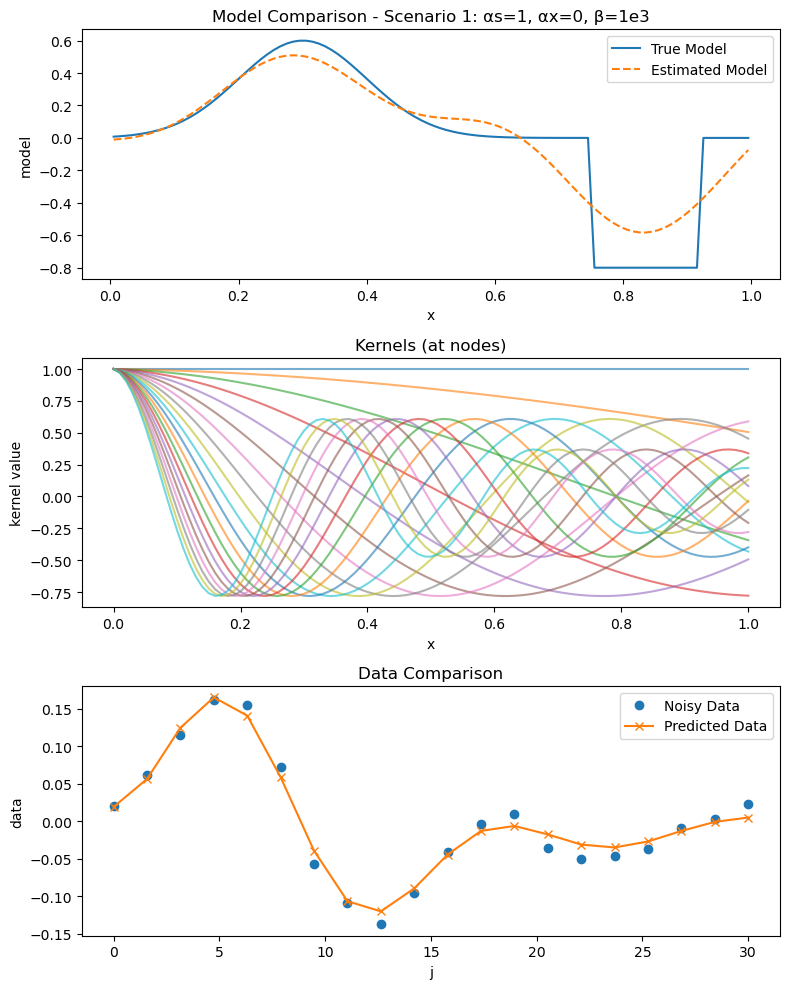

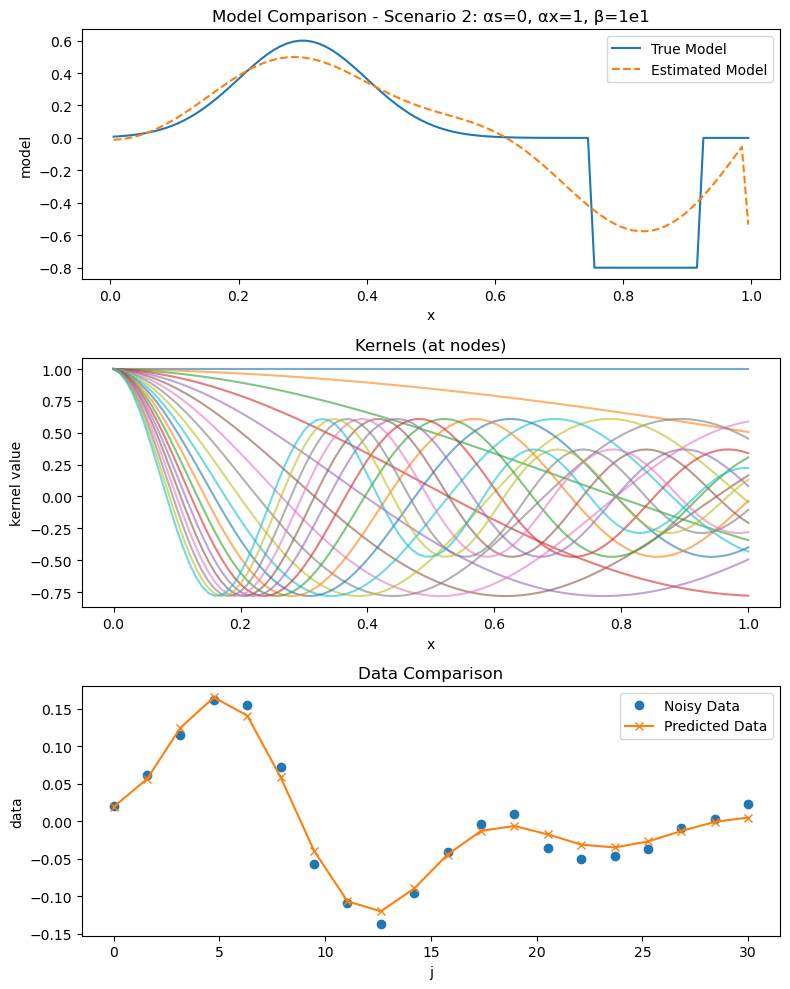

In [289]:
def estimate_model(G, data, std, x_nodes, beta, alpha_s, alpha_x):

    Wd = get_Wd(G.shape[0], std)
    Ws = get_Ws(x_nodes)
    Wx = get_Wx(x_nodes)
    phi_d_term = G.T @ Wd.T @ Wd @ G
    phi_s_term = beta * alpha_s * Ws.T @ Ws
    phi_x_term = beta * alpha_x * Wx.T @ Wx
    lhs = phi_d_term + phi_s_term + phi_x_term
    rhs = G.T @ Wd.T @ Wd @ data
    model_estimate = np.linalg.solve(lhs, rhs)
    dpred = G @ model_estimate
    residual = dpred - data
    phid = (Wd @ residual).T @ (Wd @ residual)
    phim = (Ws @ model_estimate).T @ (Ws @ model_estimate)  + (Wx @ model_estimate).T @ (Wx @ model_estimate)
    return model_estimate, dpred, phid, phim

p = -0.05
q = 0.1
#scenario 1
std = 0.01
G = build_g_mtx(x_nodes, n_kernels, p=-0.05, q = 0.1, j0 = 0, jN = 30)
true_model = build_model(x_cells, amplitude_boxcar = boxcar_amplitude, gaussian_amplitude = gaussian_amplitude)
data = G @ true_model
noise = np.random.normal(0, std, size=data.shape)
data_noisy = data + noise

N = len(data)
beta_values = [1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]

print(f"Target phi_d: {N}")

for b in beta_values:
    m_rec, d_pred, phi_d, phi_m = estimate_model(G, data_noisy, std, x_nodes, b, alpha_s=1, alpha_x=0)
    
    print(f"Beta: {b:1.0e} |  phi_d: {phi_d:.2f}")


beta_scenario1 = 1e3
estimated_model_scenario1, dpred, _, _ = estimate_model(G, data_noisy, std, x_nodes, beta_scenario1, alpha_s=1, alpha_x=0)


print(f"Target phi_d: {N}")

for b in beta_values:
    m_rec, d_pred, phi_d, phi_m = estimate_model(G, data_noisy, std, x_nodes, b, alpha_s=0, alpha_x=1)
    
    print(f"Beta: {b:1.0e} |  phi_d: {phi_d:.2f}")

#scenario 2
beta_scenario2 = 1e1
estimated_model_scenario2, dpred, _, _ = estimate_model(G, data_noisy, std, x_nodes, beta_scenario2, alpha_s=0, alpha_x=1)

#plot results

def plot_results(true_model, estimated_model, G, data_noisy, dpred, title):
    j_values = np.linspace(0, 30, G.shape[0])
    fig, axes = plt.subplots(3, 1, figsize=(8, 10))

    # model (cell-centered)
    axes[0].plot(x_cells, true_model, label='True Model')
    axes[0].plot(x_cells, estimated_model, label='Estimated Model', linestyle='--')
    axes[0].set_title(f'Model Comparison - {title}')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('model')
    axes[0].legend()

    # kernels (sampled at nodes)
    for jk in j_values:
        axes[1].plot(x_nodes, generate_kernel(x_nodes, jk, p=-0.05, q=0.1), alpha=0.6)
    axes[1].set_title('Kernels (at nodes)')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('kernel value')

    # observed vs predicted data
    axes[2].plot(j_values, data_noisy, 'o', label='Noisy Data')
    axes[2].plot(j_values, dpred, 'x-', label='Predicted Data')
    axes[2].set_title('Data Comparison')
    axes[2].set_xlabel('j')
    axes[2].set_ylabel('data')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_results(true_model, estimated_model_scenario1, G, data_noisy, dpred, title="Scenario 1: αs=1, αx=0, β=1e3")
plot_results(true_model, estimated_model_scenario2, G, data_noisy, dpred, title="Scenario 2: αs=0, αx=1, β=1e1")




## Problem 3: Tikhonov Curves

In [ ]:
def plot_tikhonov_inv_results(beta_values, phid, phim, dpred, mrecs, dobs, x_cells, G, model, alpha_x, alpha_s, n_kernels=n_kernels,beta_index=0, ax=None): 
    if ax is None: 
        fig, ax = plt.subplots(2, 3, figsize=(12, 8)) 
    
    ax[0][0].semilogx(beta_values, phid)
    ax[0][1].semilogx(beta_values, phim)
    ax[0][2].loglog(phim, phid) 

    # plot beta at the beta index
    ax[0][0].semilogx(beta_values[beta_index], phid[beta_index], "ro")
    ax[0][1].semilogx(beta_values[beta_index], phim[beta_index], "ro")
    ax[0][2].loglog(phim[beta_index], phid[beta_index], "ro")
    
    ax[0][0].set_ylabel("$\\phi_d$")
    ax[0][1].set_ylabel("$\\phi_m$")
    
    ax[0][2].set_xlabel("$\\phi_m$")
    ax[0][2].set_ylabel("$\\phi_d$")
    
    # add our target misfit 
    ax[0][0].semilogx(beta_values, np.ones(len(beta_values))*n_kernels, "--k")
    ax[0][2].loglog(phim, np.ones(len(phim))*n_kernels, "--k")

    #add star at location of largest beta where phi_d <= n_kernels
    valid_betas = beta_values[phid >= n_kernels]

    if len(valid_betas) > 0:
        max_valid_beta = valid_betas[-1]
        max_valid_beta_index = np.where(beta_values == max_valid_beta)[0][0]
        ax[0][0].semilogx(max_valid_beta, phid[max_valid_beta_index], "r*", markersize=10)
        ax[0][2].loglog(phim[max_valid_beta_index], phid[max_valid_beta_index], "r*", markersize=10)
        print(f"Star at beta={max_valid_beta:.2e}, phi_d={phid[max_valid_beta_index]:.2f}, phi_m={phim[max_valid_beta_index]:.2f}, idx={max_valid_beta_index}")

    for a in (ax[0][0], ax[0][1]):
        a.invert_xaxis()
        a.set_xlabel("$\\beta$")
    
    ax[1][1].plot(x_cells, G.T)
    
    # plot our observed data 
    ax[1][2].plot(dobs, "o", label="observed data")
    ax[1][2].plot(dpred[:, beta_index], "-s", label="predicted data")
    
    ax[1][0].plot(x_cells, model, label="true model")
    ax[1][0].plot(x_cells, mrecs[:, beta_index], label="recovered model")
    
    ax[1][1].set_xlabel("x")
    ax[1][1].set_ylabel("kernel value")
    
    ax[1][2].set_xlabel("data index")
    ax[1][2].set_ylabel("data value")
    
    ax[1][0].set_xlabel("x")
    ax[1][0].set_ylabel("model value")
    
    ax[1][2].legend()
    ax[1][0].legend()

    #add title to whole figure
    fig.suptitle(f"Tikhonov Inversion Results for beta = {beta_values[beta_index]:.2f}, alpha_s = {alpha_s}, alpha_x = {alpha_x}")
    
    plt.tight_layout()

<class 'int'>
Star at beta=6.55e+02, phi_d=20.53, phi_m=10.74, idx=13


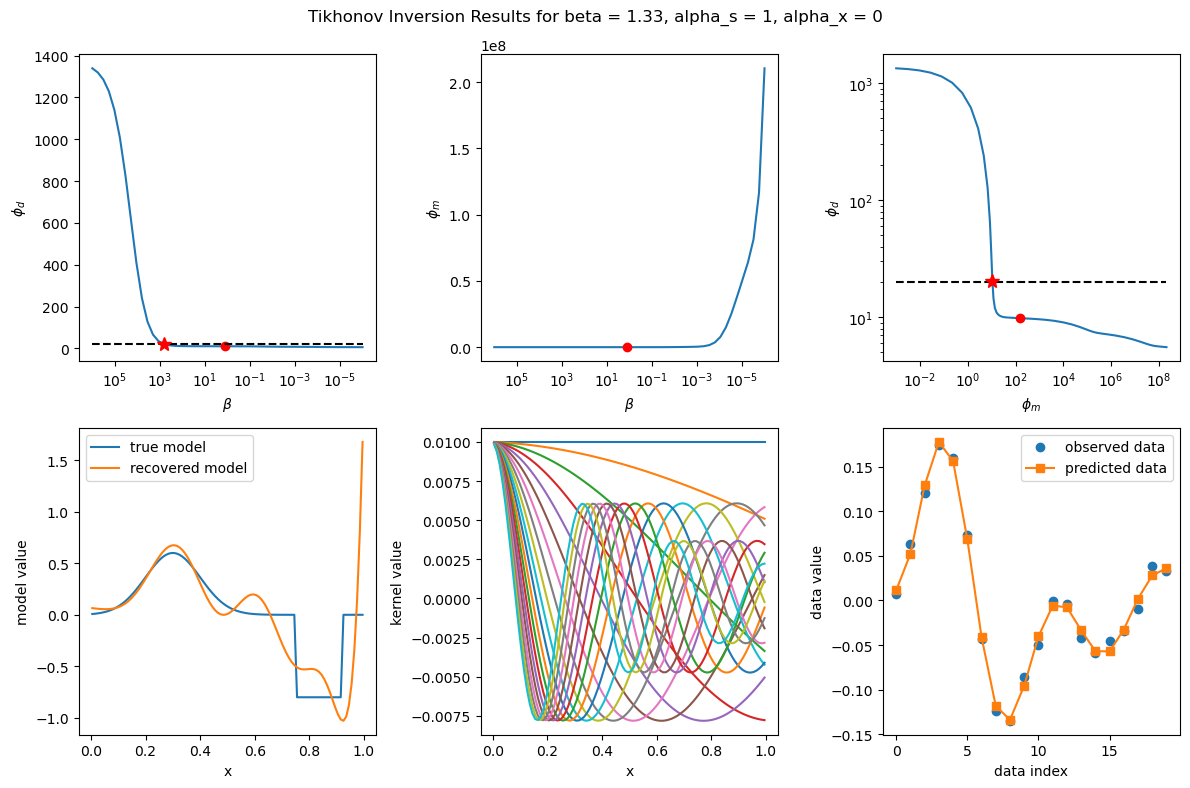

In [225]:
n_betas = 50

beta_values = np.logspace(6, -6, n_betas)
phid = np.zeros(n_betas)
phim = np.zeros(n_betas)

mrecs = np.zeros((n_cells, n_betas))
dpreds = np.zeros((n_kernels, n_betas))

for i, beta in enumerate(beta_values): 
    mrecs[:, i], dpreds[:, i], phid[i], phim[i] = estimate_model(G, data_noisy, std, x_nodes, beta, alpha_s=1, alpha_x=0)
print(type(n_kernels))
plot_tikhonov_inv_results(beta_values, phid, phim, dpreds, mrecs, data_noisy, x_cells, G, model, alpha_s=1, alpha_x=0, beta_index=24)

<class 'int'>
Star at beta=5.18e-05, phi_d=20.92, phi_m=60809.92, idx=42


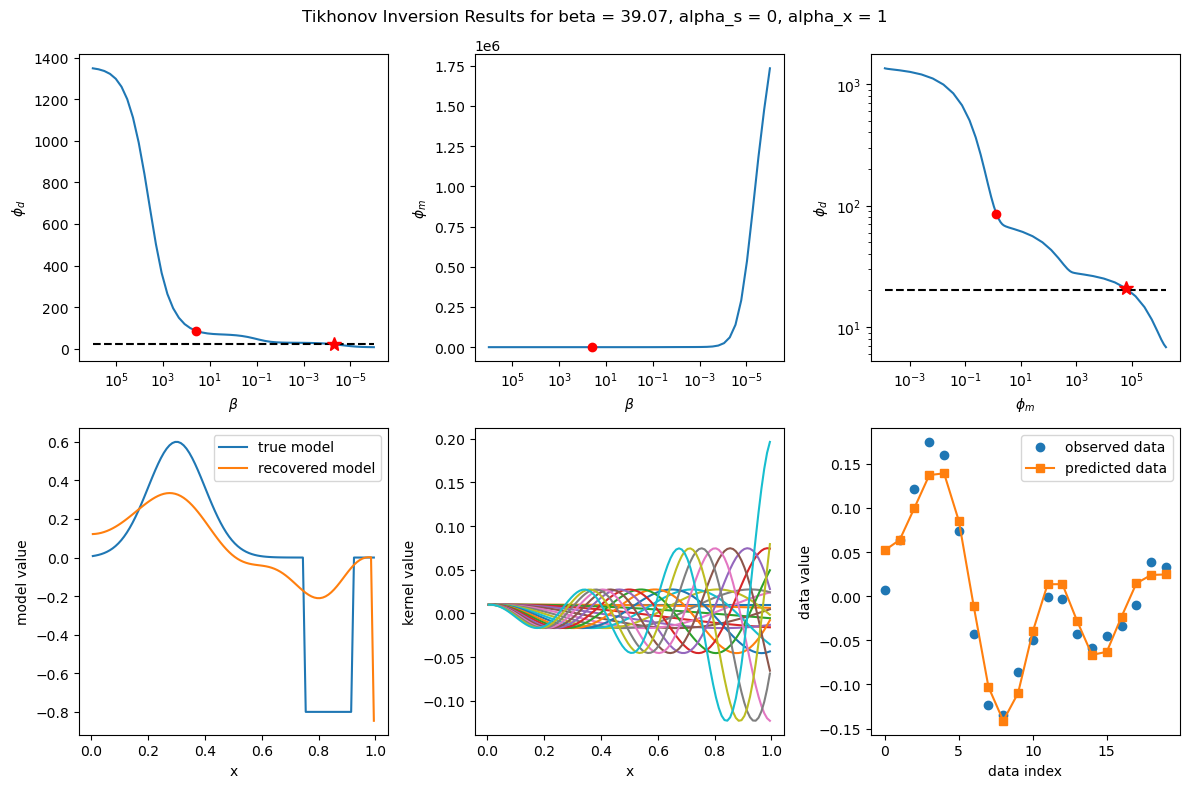

In [202]:
for i, beta in enumerate(beta_values): 
    mrecs[:, i], dpreds[:, i], phid[i], phim[i] = estimate_model(G, data_noisy, std, x_nodes, beta, alpha_s=0, alpha_x=1)
print(type(n_kernels))
plot_tikhonov_inv_results(beta_values, phid, phim, dpreds, mrecs, data_noisy, x_cells, G, model, alpha_s=0, alpha_x=1, beta_index=18)

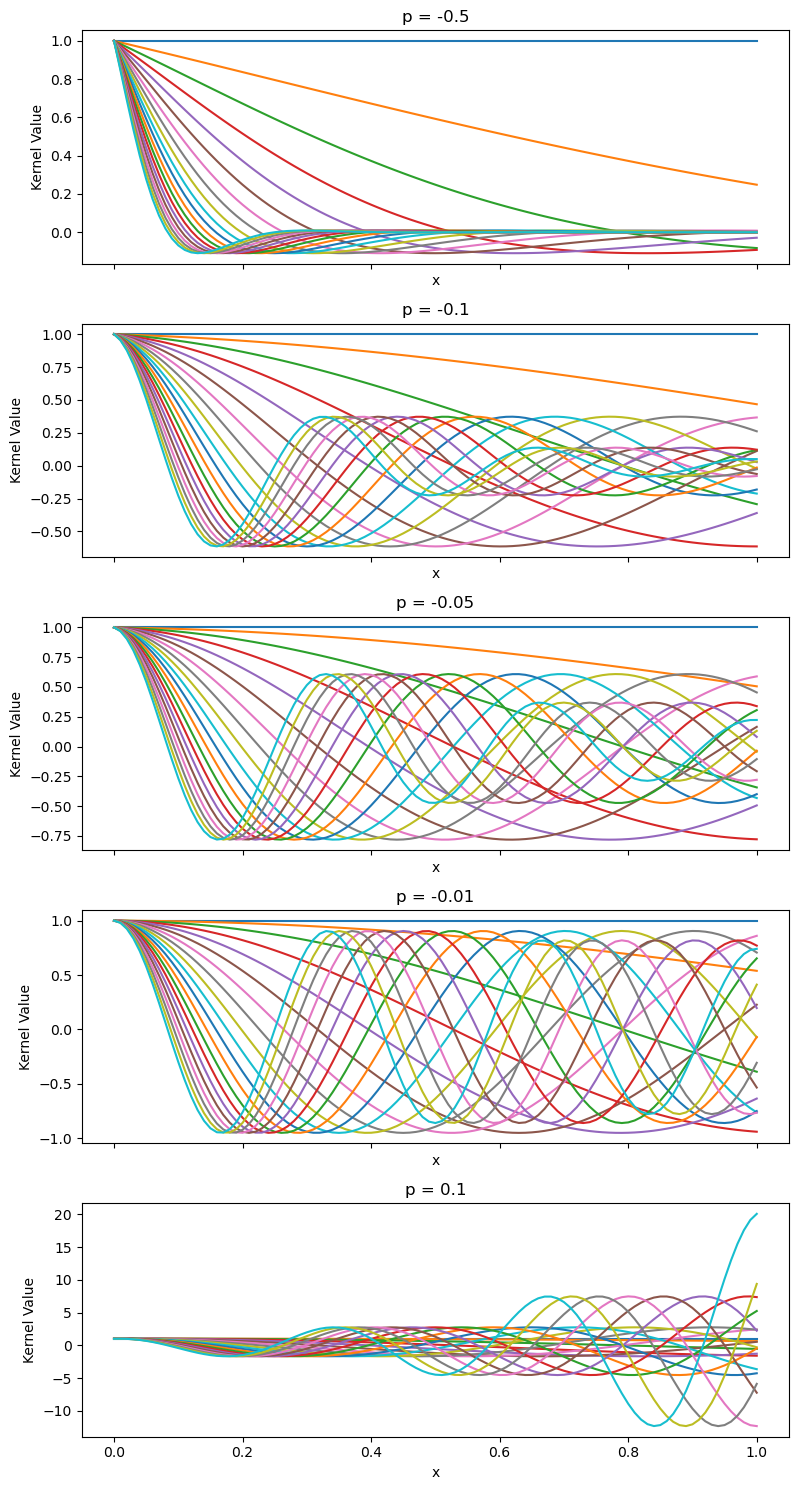

In [ ]:
# explore changing our kernel parameters and see how it affects our inversion results
p_vals = [-0.5, -0.1, -0.05, -0.01, 0.1]
#generate plot for each set of kernel parameters
fig, ax = plt.subplots(len(p_vals), 1, figsize=(8, 3*len(p_vals)), sharex=True)
for i, p in enumerate(p_vals):
    for jk in j_values:
        kernel = generate_kernel(x_nodes, jk, p, q)
        ax[i].plot(x_nodes, kernel)
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("Kernel Value")
    ax[i].set_title(f"p = {p}")
plt.tight_layout()
plt.show()

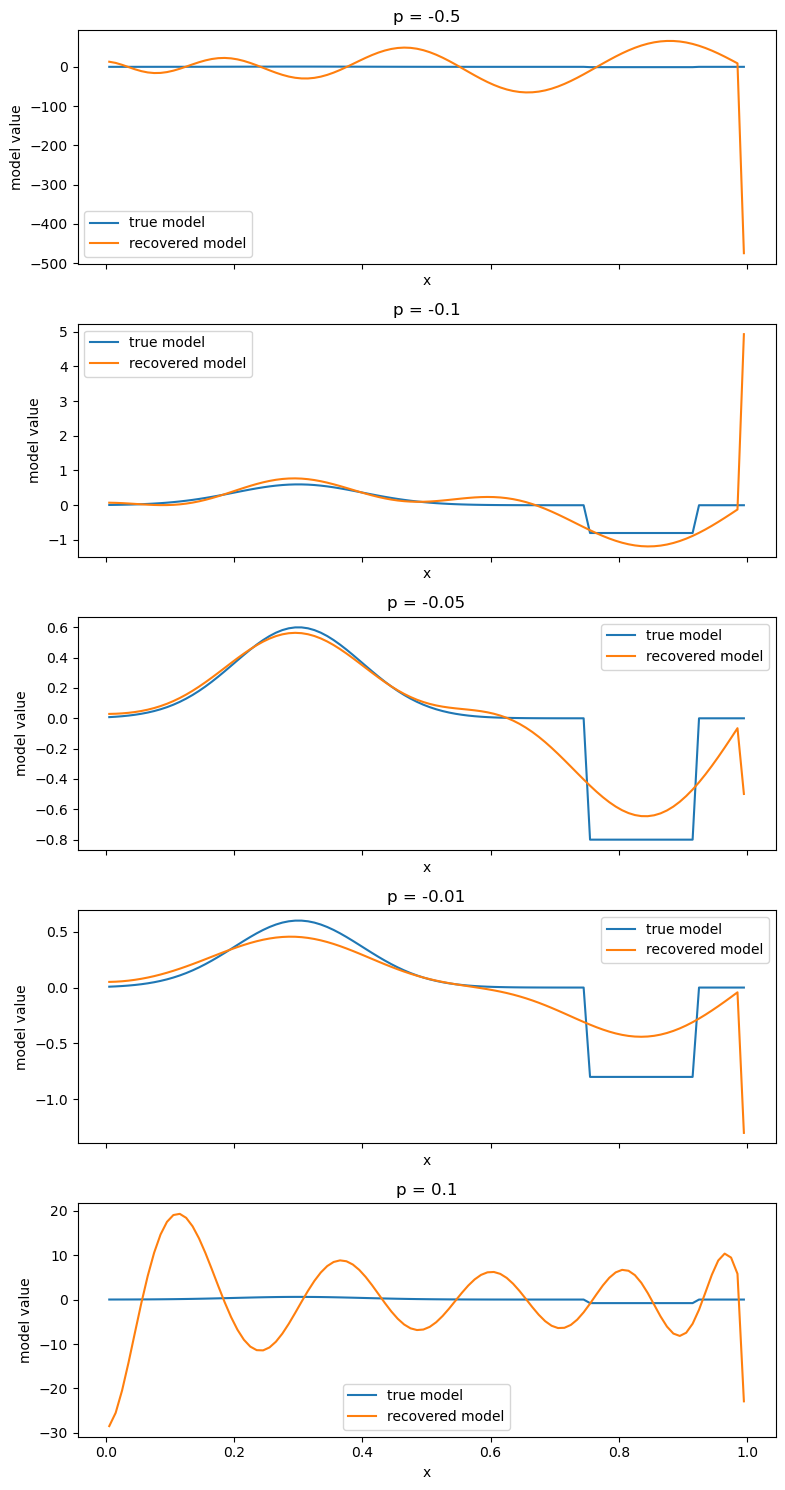

In [ ]:
#explore how changing p affects the inversion results
p_vals = [-0.5, -0.1, -0.05, -0.01, 0.1]
ideal_beta_indices = [43,24,21,19,42]
fig, ax = plt.subplots(len(p_vals), 1, figsize=(8, 3*len(p_vals)), sharex=True)
for i, p in enumerate(p_vals):
    G = build_g_mtx(x_nodes, n_kernels, p, q, j0, jN)
    mrecs = np.zeros((n_cells, n_betas))
    dpreds = np.zeros((n_kernels, n_betas))
    phid = np.zeros(n_betas)
    phim = np.zeros(n_betas)
    for j, beta in enumerate(beta_values): 
        mrecs[:, j], dpreds[:, j], phid[j], phim[j] = estimate_model(G, data_noisy, std, x_nodes, beta, alpha_s=1, alpha_x=1)

    #plot model vs recovered model for ideal beta
    ax[i].plot(x_cells, model, label="true model")
    ax[i].plot(x_cells, mrecs[:, ideal_beta_indices[i]], label="recovered model")
    ax[i].set_title(f"p = {p}")
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("model value")
    ax[i].legend()
    #plot_tikhonov_inv_results(beta_values, phid, phim, dpreds, mrecs, data_noisy, x_cells, G, model, alpha_s=1, alpha_x=1, beta_index=ideal_beta_indices[i])
plt.tight_layout()


## Problem 4: Singular Value Decomposition

Text(0.5, 1.0, 'First few singular vectors')

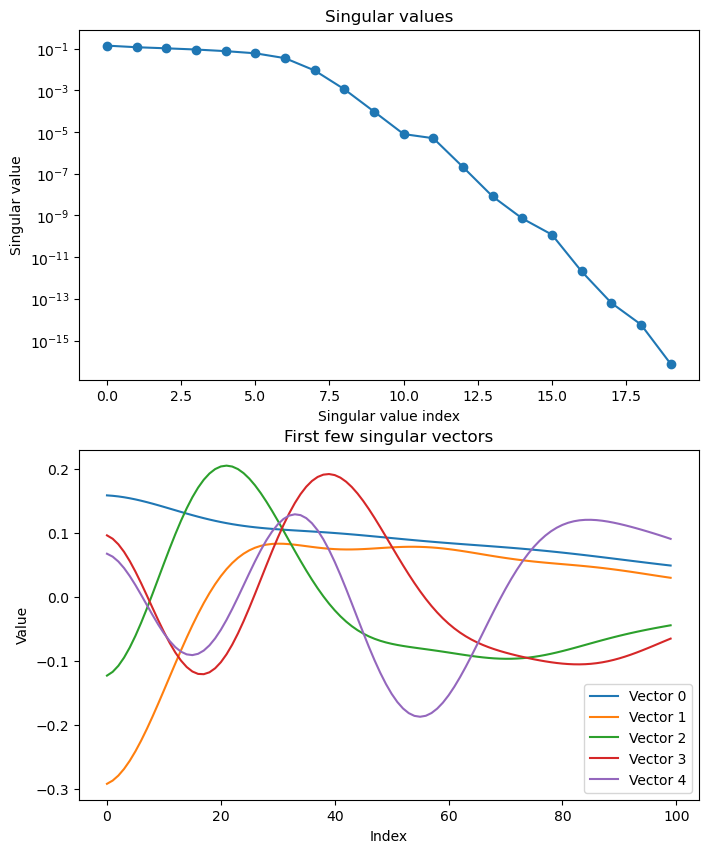

In [216]:
G = build_g_mtx(x_nodes, n_kernels, p=-0.05, q=0.1, j0=0, jN=30)
U, S, Vt = np.linalg.svd(G, full_matrices=False)

# plot singular values and vectors
fig, ax = plt.subplots(2, 1, figsize=(8, 10))
ax[0].plot(S, 'o-')
ax[0].set_xlabel('Singular value index')
ax[0].set_ylabel('Singular value')
ax[0].set_title('Singular values')
ax[0].set_yscale('log')

# plot first few singular vectors
for i in range(min(5, len(Vt))):
    ax[1].plot(Vt[i], label=f'Vector {i}')
ax[1].set_xlabel('Index')
ax[1].set_ylabel('Value')
ax[1].legend()
ax[1].set_title('First few singular vectors')

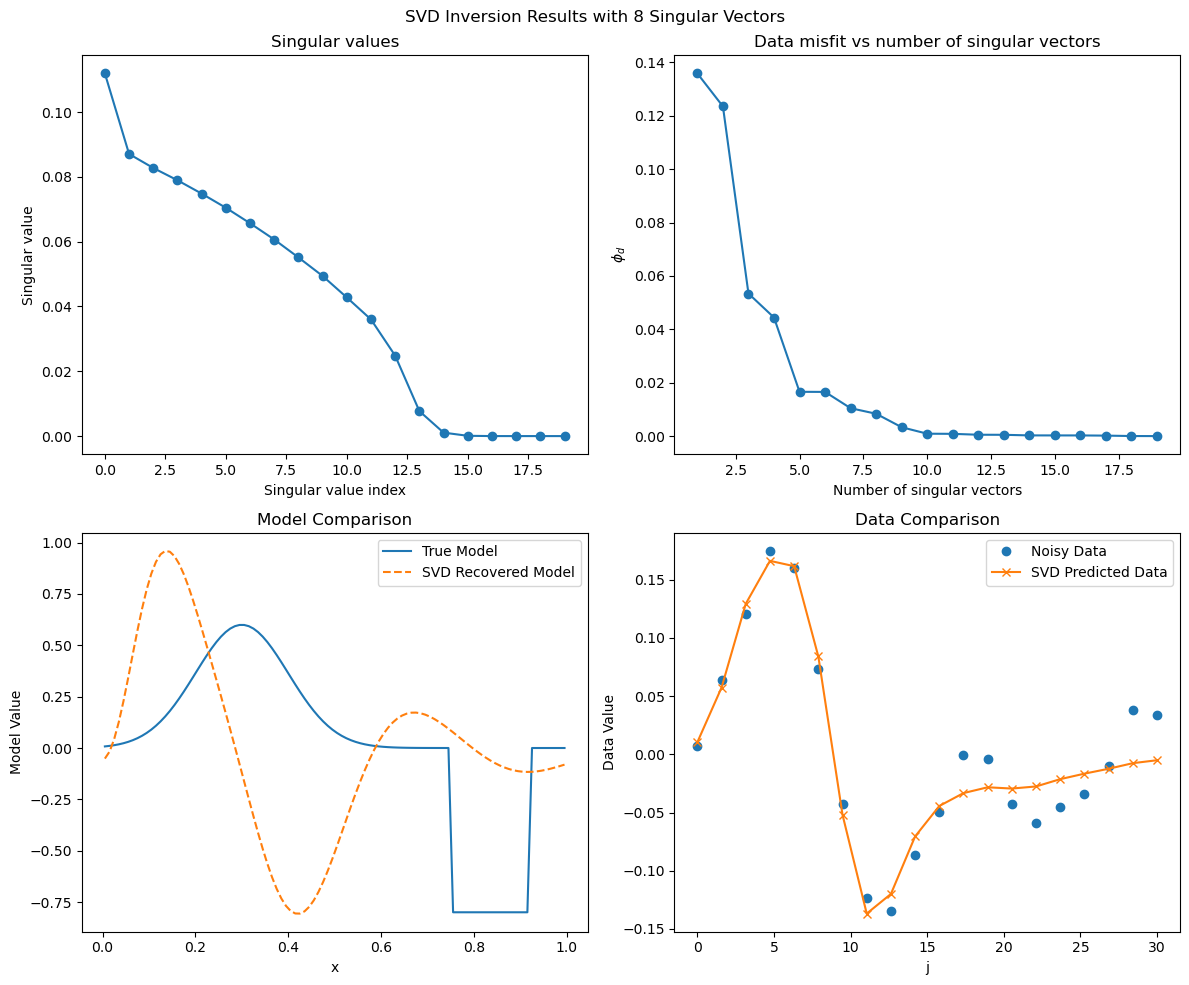

In [269]:
def get_m_svd(U, S, Vt, obs_data, n_sv):
    m_svd = np.zeros(Vt.shape[1])
    for i in range(n_sv):
        ui = U[:, i]
        vi = Vt[i, :]
        si = S[i]
        contribution = (ui.T @ obs_data) / si * vi
        m_svd += contribution
    return m_svd

    """Generate a plot that shows: (a) the singular values, (b) the data
misfit as a function of the number of singular vectors used to construct the solution
(similar to the top left plot in Figure 1, but replacing β on the x axis with p, (c) the
true and predicted models, and (d) predicted and observed data.
"""
sv_idx = 7
n_sv_values = range(1, min(20, len(S)))
misfits = []
for n_sv in n_sv_values:
    m_svd = get_m_svd(U, S, Vt, data_noisy, n_sv)
    d_pred_svd = G @ m_svd
    misfit = np.linalg.norm(d_pred_svd - data_noisy)**2
    misfits.append(misfit)
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0][0].plot(S, 'o-')
ax[0][0].set_xlabel('Singular value index')
ax[0][0].set_ylabel('Singular value')
ax[0][0].set_title('Singular values')
ax[0][1].plot(n_sv_values, misfits, 'o-')
ax[0][1].set_xlabel('Number of singular vectors')
ax[0][1].set_ylabel('$\phi_d$')
ax[0][1].set_title('Data misfit vs number of singular vectors')
m_svd_final = get_m_svd(U, S, Vt, data_noisy, n_sv_values[sv_idx])
d_pred_final = G @ m_svd_final
ax[1][0].plot(x_cells, model, label='True Model')
ax[1][0].plot(x_cells, m_svd_final, label='SVD Recovered Model', linestyle='--')
ax[1][0].set_xlabel('x')
ax[1][0].set_ylabel('Model Value')
ax[1][0].set_title('Model Comparison')
ax[1][0].legend()
ax[1][1].plot(j_values, data_noisy, 'o', label='Noisy Data')
ax[1][1].plot(j_values, d_pred_final, 'x-', label='SVD Predicted Data')
ax[1][1].set_xlabel('j')
ax[1][1].set_ylabel('Data Value')
ax[1][1].set_title('Data Comparison')
ax[1][1].legend()
fig.suptitle(f'SVD Inversion Results with {n_sv_values[sv_idx]} Singular Vectors')
plt.tight_layout()


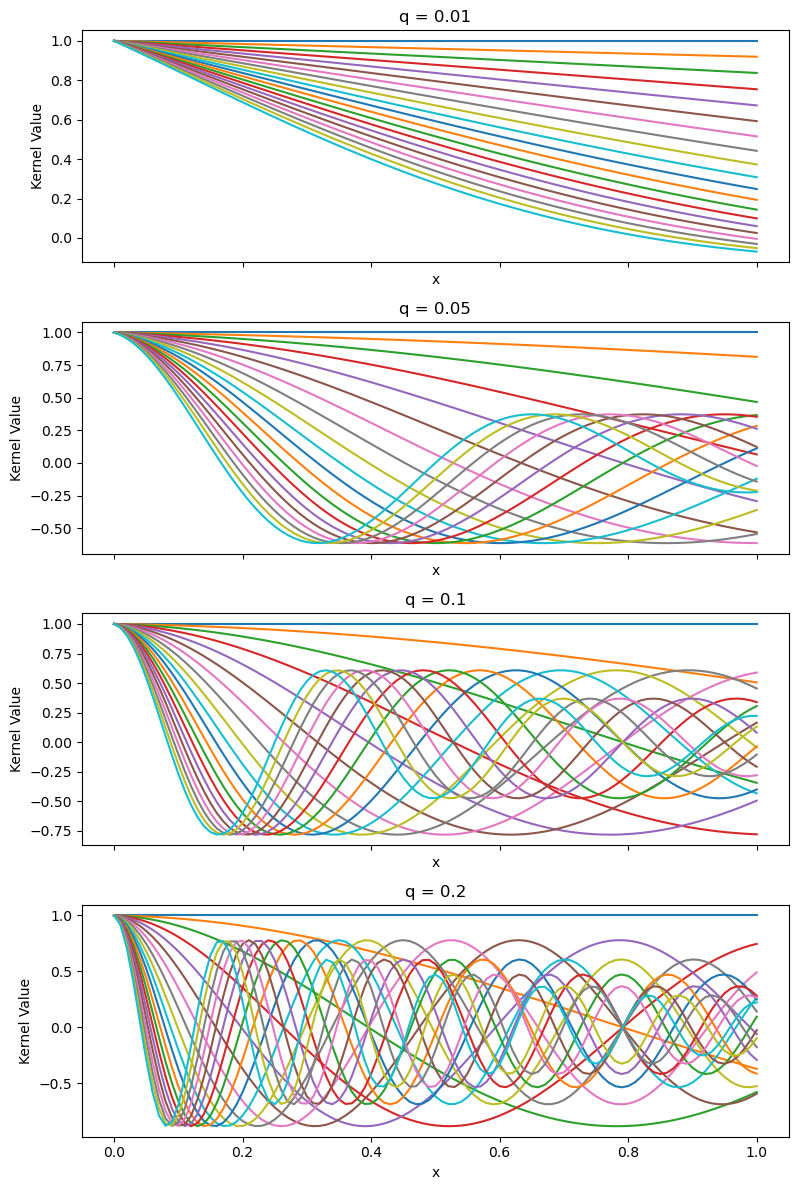

In [270]:
# explore changing our kernel parameters and see how it affects our inversion results
q_vals = [0.01, 0.05, 0.1, 0.2]
p = -0.05
#generate plot for each set of kernel parameters
fig, ax = plt.subplots(len(q_vals), 1, figsize=(8, 3*len(q_vals)), sharex=True)
for i, q_val in enumerate(q_vals):
    for jk in j_values:
        kernel = generate_kernel(x_nodes, jk, p, q_val)
        ax[i].plot(x_nodes, kernel)
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("Kernel Value")
    ax[i].set_title(f"q = {q_val}")
plt.tight_layout()
plt.show()

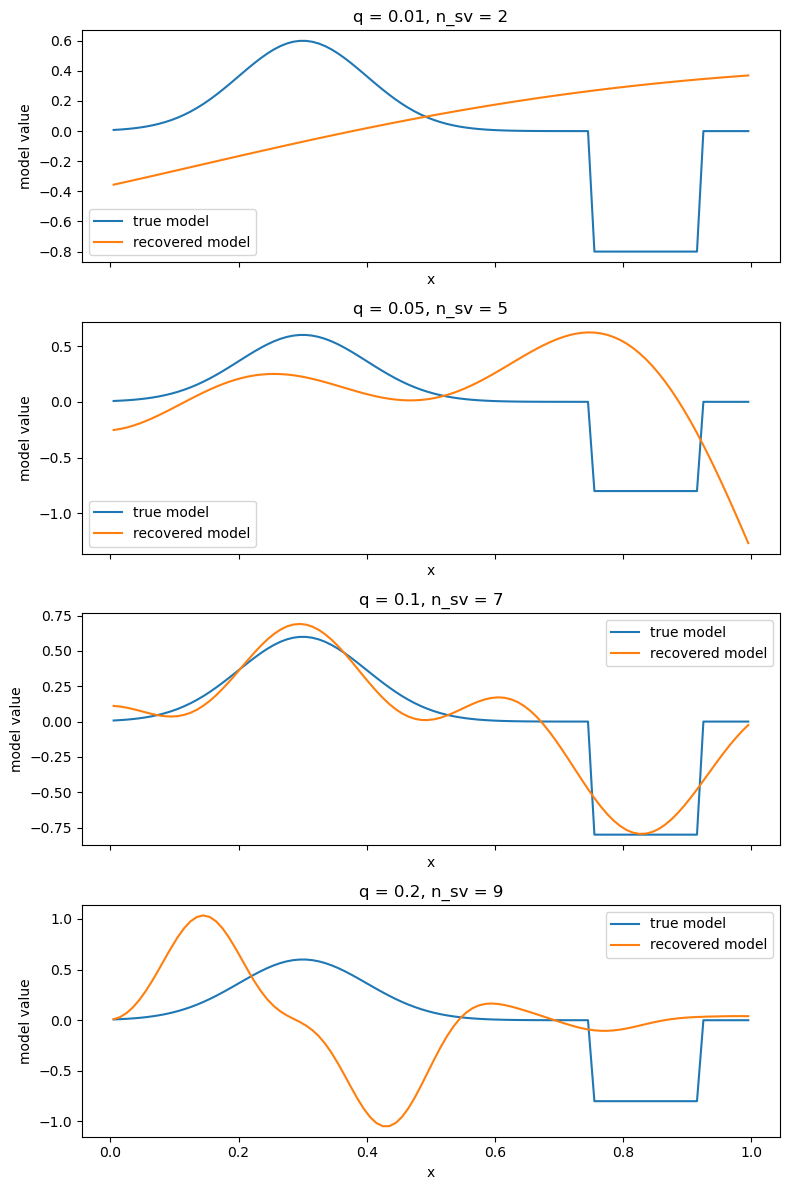

In [286]:
#try making the kernels more oscillatory and see how it affects the model outputs
q_vals = [0.01, 0.05, 0.1, 0.2]
sv_indices = [1, 4, 6, 8]
p = -0.05
fig, ax = plt.subplots(len(q_vals), 1, figsize=(8, 3*len(q_vals)), sharex=True)
for i, q_val in enumerate(q_vals):
    G = build_g_mtx(x_nodes, n_kernels, p, q_val, j0, jN)
    U, S, Vt = np.linalg.svd(G, full_matrices=False)
    mrec = get_m_svd(U, S, Vt, data_noisy, n_sv_values[sv_indices[i]])
    

    #plot model vs recovered model for ideal beta
    ax[i].plot(x_cells, model, label="true model")
    ax[i].plot(x_cells, mrec, label="recovered model")
    ax[i].set_title(f"q = {q_val}, n_sv = {n_sv_values[sv_indices[i]]}")
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("model value")
    ax[i].legend()
    #plot_tikhonov_inv_results(beta_values, phid, phim, dpreds, mrecs, data_noisy, x_cells, G, model, alpha_s=1, alpha_x=1, beta_index=ideal_beta_indices[i])
plt.tight_layout()